# 6. Variational Autoencoder (VAE)

This notebook implements a tabular VAE under two regimes:

1. **Semi-supervised VAE** trained on legitimate transactions only.
2. **Supervised VAE** trained on the full training set with fraud-weighted reconstruction loss.

Anomaly score = **reconstruction error + β × KL divergence**.


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix, f1_score

sns.set_style('whitegrid')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path().resolve().parent
with open(ROOT / 'data/processed/dataset_info.json', 'r') as f:
    info = json.load(f)

train_ieee = pd.read_parquet(ROOT / 'data/processed/ieee_train.parquet')
test_ieee  = pd.read_parquet(ROOT / 'data/processed/ieee_test.parquet')

raw_ieee = info['ieee']['raw_features']
eng_ieee = info['ieee']['engineered_features']
all_ieee = raw_ieee + eng_ieee

y_train = train_ieee['isFraud'].values
y_test  = test_ieee['isFraud'].values

X_train = train_ieee[all_ieee].fillna(-999).copy()
X_test  = test_ieee[all_ieee].fillna(-999).copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


Device: cpu


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, hidden_1=128, hidden_2=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1), nn.ReLU(),
            nn.Linear(hidden_1, hidden_2), nn.ReLU()
        )
        self.mu = nn.Linear(hidden_2, latent_dim)
        self.logvar = nn.Linear(hidden_2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_2), nn.ReLU(),
            nn.Linear(hidden_2, hidden_1), nn.ReLU(),
            nn.Linear(hidden_1, input_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar, z


def make_loader(X, y=None, batch_size=1024, shuffle=True):
    x_tensor = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(x_tensor)
    else:
        y_tensor = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def vae_loss(x, x_hat, mu, logvar, beta=0.1):
    recon = ((x - x_hat) ** 2).mean(dim=1)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1) / x.shape[1]
    return recon, kl, recon + beta * kl


def train_vae(model, loader, epochs=20, lr=1e-3, beta=0.1, weight_mode='uniform'):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()
        losses = []
        for batch in loader:
            if len(batch) == 1:
                xb = batch[0].to(DEVICE)
                yb = None
            else:
                xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)

            optimizer.zero_grad()
            x_hat, mu, logvar, _ = model(xb)
            recon, kl, total = vae_loss(xb, x_hat, mu, logvar, beta=beta)
            if weight_mode == 'fraud_weighted' and yb is not None:
                weights = torch.where(yb > 0, torch.tensor(8.0, device=DEVICE), torch.tensor(1.0, device=DEVICE))
                loss = (total * weights).mean()
            else:
                loss = total.mean()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        history.append(np.mean(losses))
        print(f"Epoch {epoch+1:02d}/{epochs} - loss: {history[-1]:.6f}")
    return history


@torch.no_grad()
def score_vae(model, X, beta=0.1, batch_size=2048):
    model.eval()
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    scores, latents = [], []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        x_hat, mu, logvar, z = model(xb)
        recon, kl, total = vae_loss(xb, x_hat, mu, logvar, beta=beta)
        scores.append(total.cpu().numpy())
        latents.append(mu.cpu().numpy())
    return np.concatenate(scores), np.concatenate(latents)


def evaluate_scores(y_true, scores, label='model'):
    auprc = average_precision_score(y_true, scores)
    roc = roc_auc_score(y_true, scores)
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_vals = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = np.argmax(f1_vals)
    thr = thresholds[best_idx]
    y_pred = (scores >= thr).astype(int)
    metrics = {
        'model': label,
        'AUPRC': auprc,
        'ROC_AUC': roc,
        'best_f1_threshold': float(thr),
        'best_f1': float(f1_score(y_true, y_pred)),
        'precision_at_best_f1': float(precision[:-1][best_idx]),
        'recall_at_best_f1': float(recall[:-1][best_idx]),
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist()
    }
    return metrics, (precision, recall, thresholds)


In [4]:
# SEMI-SUPERVISED VAE
X_train_normal = X_train_scaled[y_train == 0]
vae_semi = VAE(input_dim=X_train_scaled.shape[1], latent_dim=12)
semi_loader = make_loader(X_train_normal, batch_size=1024, shuffle=True)
semi_history = train_vae(vae_semi, semi_loader, epochs=20, lr=1e-3, beta=0.1, weight_mode='uniform')
semi_scores, semi_latent = score_vae(vae_semi, X_test_scaled, beta=0.1)
semi_metrics, semi_curve = evaluate_scores(y_test, semi_scores, label='VAE_SemiSupervised')
pd.Series(semi_metrics)


Epoch 01/20 - loss: 0.393391
Epoch 02/20 - loss: 0.184200
Epoch 03/20 - loss: 0.159334
Epoch 04/20 - loss: 0.148990
Epoch 05/20 - loss: 0.141467
Epoch 06/20 - loss: 0.134500
Epoch 07/20 - loss: 0.129966
Epoch 08/20 - loss: 0.126132
Epoch 09/20 - loss: 0.122777
Epoch 10/20 - loss: 0.119367
Epoch 11/20 - loss: 0.116615
Epoch 12/20 - loss: 0.114320
Epoch 13/20 - loss: 0.112408
Epoch 14/20 - loss: 0.110547
Epoch 15/20 - loss: 0.108941
Epoch 16/20 - loss: 0.107468
Epoch 17/20 - loss: 0.106051
Epoch 18/20 - loss: 0.104963
Epoch 19/20 - loss: 0.103735
Epoch 20/20 - loss: 0.102996


model                               VAE_SemiSupervised
AUPRC                                          0.06164
ROC_AUC                                       0.649195
best_f1_threshold                             0.184076
best_f1                                        0.11786
precision_at_best_f1                          0.078991
recall_at_best_f1                             0.232037
confusion_matrix        [[103049, 10995], [3121, 943]]
dtype: object

In [5]:
# SUPERVISED VAE
vae_sup = VAE(input_dim=X_train_scaled.shape[1], latent_dim=12)
sup_loader = make_loader(X_train_scaled, y_train, batch_size=1024, shuffle=True)
sup_history = train_vae(vae_sup, sup_loader, epochs=20, lr=1e-3, beta=0.1, weight_mode='fraud_weighted')
sup_scores, sup_latent = score_vae(vae_sup, X_test_scaled, beta=0.1)
sup_metrics, sup_curve = evaluate_scores(y_test, sup_scores, label='VAE_Supervised')
pd.Series(sup_metrics)


Epoch 01/20 - loss: 0.581538
Epoch 02/20 - loss: 0.274436
Epoch 03/20 - loss: 0.226589
Epoch 04/20 - loss: 0.206413
Epoch 05/20 - loss: 0.193305
Epoch 06/20 - loss: 0.185621
Epoch 07/20 - loss: 0.178016
Epoch 08/20 - loss: 0.174855
Epoch 09/20 - loss: 0.167672
Epoch 10/20 - loss: 0.164493
Epoch 11/20 - loss: 0.160789
Epoch 12/20 - loss: 0.157577
Epoch 13/20 - loss: 0.154905
Epoch 14/20 - loss: 0.153118
Epoch 15/20 - loss: 0.150240
Epoch 16/20 - loss: 0.148204
Epoch 17/20 - loss: 0.146456
Epoch 18/20 - loss: 0.144668
Epoch 19/20 - loss: 0.143216
Epoch 20/20 - loss: 0.144386


model                                   VAE_Supervised
AUPRC                                         0.038698
ROC_AUC                                       0.537655
best_f1_threshold                             0.099325
best_f1                                       0.071255
precision_at_best_f1                          0.037591
recall_at_best_f1                             0.682087
confusion_matrix        [[43075, 70969], [1292, 2772]]
dtype: object

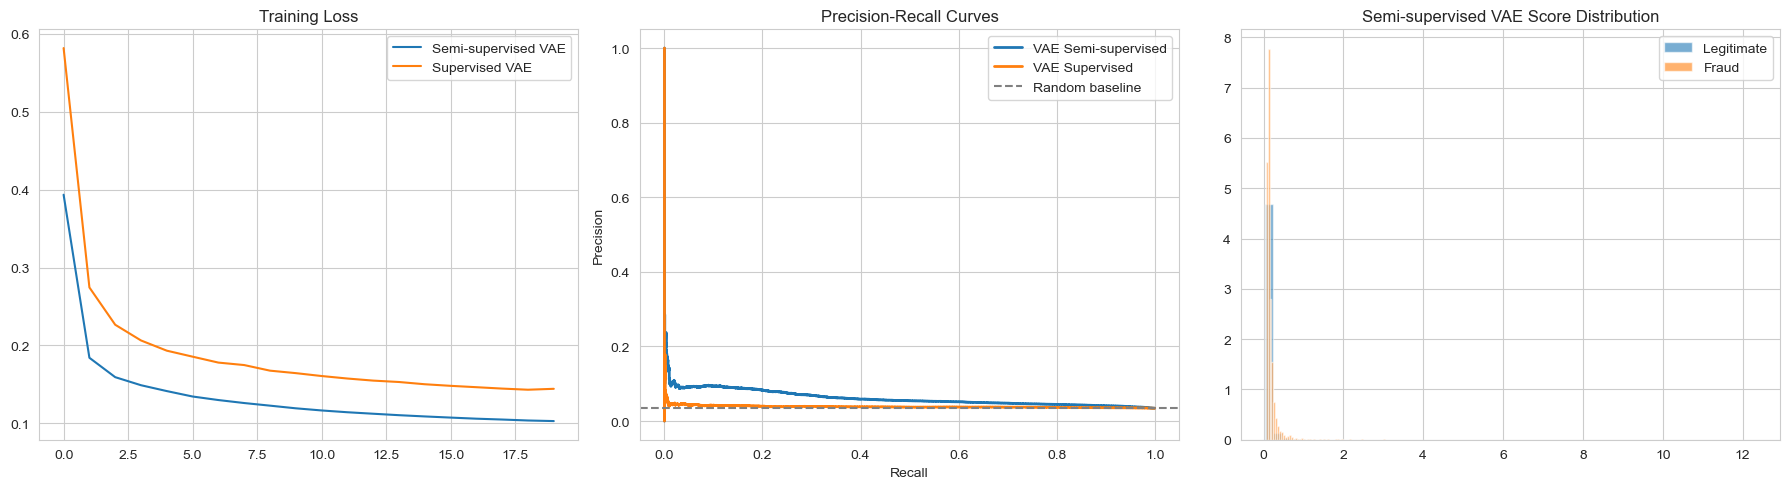

In [6]:
# VISUALS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(semi_history, label='Semi-supervised VAE')
axes[0].plot(sup_history, label='Supervised VAE')
axes[0].set_title('Training Loss')
axes[0].legend()

for curve, label in [(semi_curve, 'VAE Semi-supervised'), (sup_curve, 'VAE Supervised')]:
    p, r, _ = curve
    axes[1].plot(r, p, linewidth=2, label=label)
axes[1].axhline(y=y_test.mean(), linestyle='--', color='gray', label='Random baseline')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

axes[2].hist(semi_scores[y_test == 0], bins=60, alpha=0.6, label='Legitimate', density=True)
axes[2].hist(semi_scores[y_test == 1], bins=60, alpha=0.6, label='Fraud', density=True)
axes[2].set_title('Semi-supervised VAE Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()


In [7]:
# SAVE OUTPUTS FOR NOTEBOOK 08
results_dir = ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    'y_true': y_test,
    'vae_semi_score': semi_scores,
    'vae_supervised_score': sup_scores
}).to_csv(results_dir / 'vae_scores_ieee.csv', index=False)

summary = pd.DataFrame([semi_metrics, sup_metrics])
summary.to_csv(results_dir / 'vae_summary_ieee.csv', index=False)
summary


,model,AUPRC,ROC_AUC,best_f1_threshold,best_f1,precision_at_best_f1,recall_at_best_f1,confusion_matrix
0,VAE_SemiSupervised,0.061640,0.649195,0.184076,0.117860,0.078991,0.232037,"[[103049, 10995], [3121, 943]]"
1,VAE_Supervised,0.038698,0.537655,0.099325,0.071255,0.037591,0.682087,"[[43075, 70969], [1292, 2772]]"


In [8]:
# ECONOMIC ANALYSIS - Minimum Financial Cost
# Cost function: $500 per missed fraud (FN) + $2 per false alarm (FP)

def calculate_min_cost(y_true, scores, cost_fn=500, cost_fp=2):
    """
    Calculate minimum expected financial cost by finding optimal threshold.
    """
    thresholds = np.unique(scores)
    
    costs = []
    for th in thresholds:
        y_pred = (scores >= th).astype(int)
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        total_cost = fn * cost_fn + fp * cost_fp
        costs.append(total_cost)
    
    min_cost = np.min(costs)
    best_threshold = thresholds[np.argmin(costs)]
    
    y_pred_best = (scores >= best_threshold).astype(int)
    tp = np.sum((y_true == 1) & (y_pred_best == 1))
    fn = np.sum((y_true == 1) & (y_pred_best == 0))
    fp = np.sum((y_true == 0) & (y_pred_best == 1))
    
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    
    return {
        'min_cost': min_cost,
        'best_threshold': best_threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fn': fn,
        'fp': fp
    }

# Calculate min cost for both VAE models
print("\n" + "="*60)
print("ECONOMIC ANALYSIS ($500 per missed fraud, $2 per false alarm)")
print("="*60)

semi_cost_result = calculate_min_cost(y_test, semi_scores)
sup_cost_result = calculate_min_cost(y_test, sup_scores)

print(f"\nSemi-supervised VAE:")
print(f"  Minimum Financial Cost: ${semi_cost_result['min_cost']:,.2f}")

print(f"\nSupervised VAE:")
print(f"  Minimum Financial Cost: ${sup_cost_result['min_cost']:,.2f}")



ECONOMIC ANALYSIS ($500 per missed fraud, $2 per false alarm)

Semi-supervised VAE:
  Minimum Financial Cost: $227,972.00

Supervised VAE:
  Minimum Financial Cost: $227,972.00
